<a href="https://colab.research.google.com/github/karanbhatt1/DeepLearningModels/blob/main/catanddogclassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing neccesaary libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2 as cv
from google.colab.patches import cv2_imshow
import os
import pickle

# Connecting google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

NotImplementedError: Mounting drive is unsupported in this environment. Use PyDrive2 instead. See examples at https://colab.research.google.com/notebooks/io.ipynb#scrollTo=7taylj9wpsA2.

# Exploring some images from data set

In [ ]:
import cv2
img = cv.imread('/content/drive/MyDrive/Datasets/PetImages/Dog/12498.jpg')
print(img.shape)
cv2_imshow(img)
gray_img = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

In [ ]:
cv2_imshow(gray_img)
print(gray_img.shape)


# Dataset loading Problem in Kaggle:
-> Kaggle dosen't support direct mounting of gdrive.  
-> so using gdown to load and download it.

In [ ]:
!pip install -U -q gdown

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 kB 1.7 MB/s eta 0:00:00


In [ ]:
!gdown "https://drive.google.com/uc?id=1jVwwStfgAfu30bZE3tEAfvGXnbkqeYKs"

Using cookies from /root/.cache/gdown/cookies.txt
Downloading...
From (original): https://drive.google.com/uc?id=1jVwwStfgAfu30bZE3tEAfvGXnbkqeYKs
From (redirected): https://drive.google.com/uc?id=1jVwwStfgAfu30bZE3tEAfvGXnbkqeYKs&confirm=t&uuid=d2c61d6c-5385-43ed-9dcd-c105116e2187
To: /kaggle/working/PetImages-20260917T050932Z-1-001.zip
100%|████████████████████████████████████████| 854M/854M [00:15<00:00, 55.2MB/s]


In [ ]:
import zipfile

zip_path = "/kaggle/working/PetImages-20260917T050932Z-1-001.zip"
extract_path = "/kaggle/working/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Using Image Data Generator for directly loading from directory:
- flow_from_directory()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
i_d_g = ImageDataGenerator(
    #Normalization: Rescaling the values of matries from 1-255 to 0-1 so model can be trained fast and efficiently.
    rescale = 1./255,
    validation_split = 0.2
)

# Loadng the data and creating data generator

In [ ]:
path_kaggle = "/kaggle/working/dataset/PetImages"

In [ ]:
path  = '/content/drive/MyDrive/Datasets/PetImages'
train_data_flow = i_d_g.flow_from_directory(
    path_kaggle,
    target_size = (224,224),
    batch_size = 64,
    class_mode = 'binary',
    subset='training'
)

val_data = i_d_g.flow_from_directory(
    path_kaggle,
    target_size=(224, 224),
    batch_size=64,
    class_mode="binary",
    subset="validation"
)

Found 20000 images belonging to 2 classes.
Found 4998 images belonging to 2 classes.


In [ ]:
print(train_data_flow.class_indices)
print(val_data.class_indices)

{'Cat': 0, 'Dog': 1}
{'Cat': 0, 'Dog': 1}


# Now using Tensorflow sequential model to build a custom CNN model:

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping,ModelCheckpoint
from tensorflow.keras.optimizers import Adam

In [ ]:
# data_augment = Sequential(
#     [
#         layers.RandomFlip("horizontal"),
#         layers.RandomRotation(0.1),
#         layers.RandomZoom(0.2),
#         layers.RandomContrast(0.2),
#     ]
# )

In [ ]:
model1 = Sequential(
    [
        keras.Input(shape = (224,224,3)),
        layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Conv2D(filters=128,kernel_size=(3,3),activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Flatten(),
        layers.Dense(units=64,activation='relu'),
        layers.Dense(units=1,activation='sigmoid')
    ]
)

In [ ]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)

In [ ]:
model1.compile(optimizer= optimizer,
              loss="binary_crossentropy",
              metrics=["accuracy"])

#How These Parameters are calculates :
- Let's understand : first notice the input size (224,224,3)
- then first conv2d layer has 32 filters of size 3*3 and we have 3 channels.
- From each channel(3) the kernal moves with dimensions 3*3 which is equal to 9.
- Then 9*3 = 27 and 27 * 32 = 864 and we have 32 biases so total comes out to be 864 + 32 = 896 parameter.
- **This means parameters are weights and biases**

# What does Max_pooling Do:
- It take a highest value of pixel from each patch of specified size here is (2,2)

-So, then 222/2,222/2 => 111,111,32 we get

In [ ]:
model1.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,631,169 (21.48 MB)

 Trainable params: 5,631,169 (21.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history1 = model1.fit(train_data_flow , validation_data=val_data, epochs = 5)

In [ ]:
!nvidia-smi

In [ ]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

# Model 2
- Applying MAX Pooling and regularization to minimize the overfitting issue.
- The last model gave the accuracy of 90.25% and validation accuracy of 81.25%.
- There was in total 5 epochs so in this model there will be total of 10 epochs.

## Applying MaxPolling(2,2)
-> after each Conv2d layer we just take the maxpixel value from 2*2 matrix in images for each layer.  
-> Applying regularization layers.drop(0.2)

In [ ]:
from tensorflow.keras.optimizers import Adam

In [ ]:
def model2():
  model = Sequential(
      [
        keras.Input(shape = (224,224,3)),

        layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Dropout(0.25),

        layers.Conv2D(filters=128,kernel_size=(3,3),activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),
        layers.Dropout(0.25),

        layers.Flatten(),
        layers.Dense(units=64,activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(units=1,activation='sigmoid')
      ]
  )
  return model

In [ ]:
model_2 = model2()

In [ ]:
model_2.compile(optimizer='adam',
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [ ]:
model_2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,631,169 (21.48 MB)

 Trainable params: 5,631,169 (21.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_2 = model_2.fit(train_data_flow , validation_data=val_data, epochs = 10)

Epoch 1/10
163/313 ━━━━━━━━━━━━━━━━━━━━ 1:13:55 30s/step - accuracy: 0.5062 - loss: 0.9222

/usr/local/lib/python3.13/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


313/313 ━━━━━━━━━━━━━━━━━━━━ 11680s 37s/step - accuracy: 0.5001 - loss: 0.7211 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 323ms/step - accuracy: 0.4976 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 313ms/step - accuracy: 0.4970 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 102s 327ms/step - accuracy: 0.4996 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 321ms/step - accuracy: 0.5055 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 324ms/step - accuracy: 0.5002 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 101s 321ms/step - accuracy: 0.4979 - loss: 0.6934 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 98s 314ms/step - accuracy: 0.4992 - loss: 0.6932

In [ ]:
path_model = "/content/drive/MyDrive/Models/custom_cnn_regularized.keras"
model_2.save(path_model)

In [ ]:
path_history_2 = '/content/drive/MyDrive/Models/custom_cnn_baseline_history.csv'
history_df_2 = pd.DataFrame(history_2.history)
history_df_2.to_csv("custom_cnn_baseline_history.csv", index=False)

# Model 3:
- As model 2 was worse so i decide to move on to model 3 by doing little bit of hyperparameter tuning.
## What will change from previous Model_2:
    -> Use SGD(Stochastic Gradient Descent) as an optimizer with learning rate of 0.01.  
    -> Use drop out to prevent overfitting.  
    -> Change in architecture.  
    -> Using Different Activation function like leaky relu for preventing the Dying ReLu.[Rectified Linear Unit]
    -> Change in the kernal size from 3 * 3 to 2 * 2;  
    -> **MaxPooling** → reduces spatial dimensions gradually DURING convolutional feature extraction.  
    -> **GlobalAveragePooling** → summarizes the FINAL feature maps before classification.  
    -> Also training the model for more no of epochs with early stopping to prevent the high compute cost.

## Architecture:
- input = 224,224,3
- Conv2d = 32 , (2*2),
- maxPolling2D(2,2),
- Conv2d = 64 , (2*2)
- maxPolling2D(2,2),
- Conv2d = 128 , (2*2)
- maxPolling2D(2,2),
- Conv2d =- 256 , (2*2)
- Flatten()
- dropout(.20),
- dense layer (64)
- dense layer (32)
- dense layer (16)
- output layer

> Leaky ReLU is used to reduce the risk of "dying ReLU" neurons by allowing a small negative output instead of setting all negative inputs to zero.  

> I will investigate whether smaller 2×2 convolutional kernels can provide sufficient feature extraction while changing the model's computational/representational characteristics.

In [ ]:
path  = '/content/drive/MyDrive/Datasets/PetImages'

In [ ]:
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.layers import LeakyReLU

In [ ]:
def model_creator(activation_function,dropout_neurons):
  model = Sequential(
      [
        keras.Input(shape = (224,224,3)),

        layers.Conv2D(filters=32,kernel_size=(2,2),activation =  activation_function),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(filters=64,kernel_size=(2,2),activation = activation_function),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(filters=128,kernel_size=(2,2),activation= activation_function),
        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(filters= 256, kernel_size = (2,2), activation= activation_function),

        # layers.GlobalAveragePooling2D(),
        layers.Flatten(),
        layers.Dropout(dropout_neurons),

        layers.Dense(units=64,activation= activation_function),
        layers.Dense(units = 32, activation = activation_function),
        layers.Dense(units = 16, activation = activation_function),
        layers.Dense(units=1,activation='sigmoid')
      ]
  )
  return model

In [ ]:
activation = LeakyReLU(negative_slope = 0.01)
optimizer = SGD(learning_rate=0.01)

In [ ]:
model_3 = model_creator(activation,0.2)

In [ ]:
model_3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 223, 223, 32)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 110, 110, 64)   │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 55, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 54, 54, 128)    │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 27, 27, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 26, 26, 256)    │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 173056)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 173056)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │    11,075,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,251,169 (42.92 MB)

 Trainable params: 11,251,169 (42.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss',
                           patience=5,
                           restore_best_weights=True)

In [ ]:
kaggle_output_dir = "/kaggle/working/model/best_model.keras"

In [ ]:
checkpoint = ModelCheckpoint(
    kaggle_output_dir,
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

In [ ]:
model_3.compile(optimizer = optimizer,
                loss = ['binary_crossentropy'],
                metrics=['accuracy'])

In [ ]:
history_3 = model_3.fit(train_data_flow,
                        validation_data=val_data,
                        epochs = 50,
                        verbose = 'auto',
                        callbacks = [checkpoint,early_stop]
                      )

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.5230 - loss: 0.6918
Epoch 1: val_loss improved from None to 0.68275, saving model to /kaggle/working/model/best_model.keras

Epoch 1: finished saving model to /kaggle/working/model/best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 66s 203ms/step - accuracy: 0.5442 - loss: 0.6896 - val_accuracy: 0.5960 - val_loss: 0.6827
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.5856 - loss: 0.6792
Epoch 2: val_loss improved from 0.68275 to 0.65700, saving model to /kaggle/working/model/best_model.keras

Epoch 2: finished saving model to /kaggle/working/model/best_model.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 201ms/step - accuracy: 0.5911 - loss: 0.6738 - val_accuracy: 0.6112 - val_loss: 0.6570
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.5960 - loss: 0.6616
Epoch 3: val_loss improved from 0.65700 to 0.64351, saving model to /kaggle/working/model/best_model.keras

Epoch 3: finished saving mode

## Saving The model 3

In [ ]:
import os

save_dir = "/kaggle/working/saved_models"
os.makedirs(save_dir, exist_ok=True)

print(save_dir)

In [ ]:
path_model_3 = save_dir + "/custom_cnn_model_3.keras"
model_3.save(path_model_3)

In [ ]:
history_3_path = save_dir + "/custom_cnn3_history.csv"
history_df_3 = pd.DataFrame(history_3.history)
history_df_3.to_csv("custom_cnn3_history.csv", index=False)

## Plotting the graphs for model_3

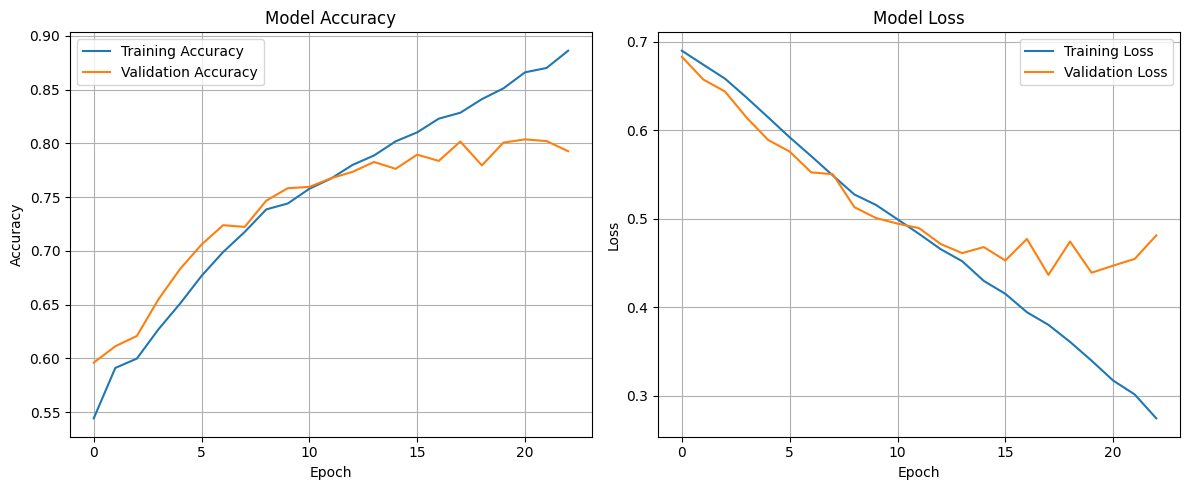

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Accuracy
ax[0].plot(history_3.history['accuracy'], label='Training Accuracy')
ax[0].plot(history_3.history['val_accuracy'], label='Validation Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].grid()
ax[0].legend()

# Loss
ax[1].plot(history_3.history['loss'], label='Training Loss')
ax[1].plot(history_3.history['val_loss'], label='Validation Loss')
ax[1].set_title('Model Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].grid()
ax[1].legend()

plt.tight_layout()
plt.show()

## Conclusion :
- There is a slight overfitting starting from epoch 12-14 between accuracy and val_accuracy
- From epoch 10-11
- But this model shows a very significant improvement from baseline and 2nd model.

## Evaluating using Classification report

In [ ]:
val_report = i_d_g.flow_from_directory(
    path_kaggle,
    target_size=(224, 224),
    batch_size=64,
    class_mode='binary',
    subset='validation',
    shuffle=False
)

Found 4998 images belonging to 2 classes.


In [ ]:
import numpy as np

pred_prob = model_3.predict(val_report)

pred = (pred_prob > 0.5).astype(int).ravel()

y_true = val_report.classes

79/79 ━━━━━━━━━━━━━━━━━━━━ 12s 150ms/step


In [ ]:
from sklearn.metrics import classification_report


In [ ]:
print(
    classification_report(
        y_true,
        pred,
        target_names=list(val_report.class_indices.keys())
    )
)

              precision    recall  f1-score   support

         Cat       0.78      0.84      0.81      2499
         Dog       0.83      0.76      0.79      2499

    accuracy                           0.80      4998
   macro avg       0.80      0.80      0.80      4998
weighted avg       0.80      0.80      0.80      4998



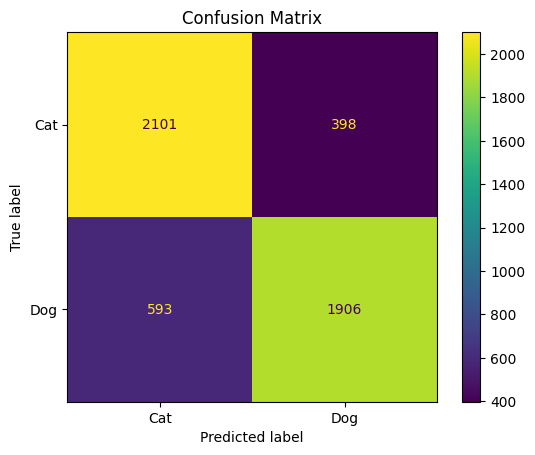

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(val_report.class_indices.keys())
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()